# t-SNE Out-of-Sample Embedding via k-NN Interpolation

This notebook tests the hypothesis that replacing the complex KL-divergence optimization with a simple spatial interpolation (k-Nearest Neighbors) can "fix" t-SNE for prediction tasks.

The interpolation algorithm:
1. For each test snapshot, find its $k$ nearest neighbors in the high-dimensional PCA space within the training set.
2. Look up the 3D t-SNE coordinates of those $k$ neighbors.
3. Place the test snapshot at the distance-weighted average of those 3D coordinates.

We test this on both the **Standard Split** (Tasks A/B) and the **Leave-Freq-Out Split** (Task D).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time, os, sys
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, r2_score

sys.path.append(os.path.abspath('.'))
import ml_experiment_utils as mlu

plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=12)
print('Setup complete.')

Setup complete.


In [2]:
# Load pre-computed global PCA scores
data = np.load('pca_data/global_forced_pca.npz')
pca_scores   = data['pca_scores']     # We use all 500 components for the k-NN distance
run_labels   = data['run_labels']
st_labels    = data['st_labels']
phase_labels = data['phase_labels']

print(f'PCA scores shape: {pca_scores.shape}')

PCA scores shape: (48720, 500)


In [3]:
def embed_new_points_knn(X_train, Y_train, X_test, k=10):
    """
    Embeds test points into a pre-computed low-dimensional space using 
    inverse-distance-weighted k-NN interpolation.
    """
    print(f"Finding {k}-NN for {len(X_test)} test points in high-dimensional space...")
    t0 = time.time()
    
    nn = NearestNeighbors(n_neighbors=k, n_jobs=-1)
    nn.fit(X_train)
    distances, indices = nn.kneighbors(X_test)
    
    # Inverse distance weighting (add small epsilon to avoid division by zero)
    weights = 1.0 / (distances + 1e-8)
    weights /= weights.sum(axis=1, keepdims=True)
    
    # Interpolate low-dimensional coordinates
    Y_test = np.zeros((X_test.shape[0], Y_train.shape[1]))
    for i in range(X_test.shape[0]):
        Y_test[i] = np.average(Y_train[indices[i]], axis=0, weights=weights[i])
        
    print(f"Interpolation completed in {time.time() - t0:.2f} seconds.")
    return Y_test

## 1. Standard Split (Tasks A & B)

In this split, training and test data come from the same experimental runs. The test data will have extremely close neighbors in the training set.

In [4]:
# Create standard split
std_train_idx, std_test_idx = mlu.create_standard_split(pca_scores, phase_labels, st_labels)

X_train_std = pca_scores[std_train_idx]
X_test_std  = pca_scores[std_test_idx]

# Fit t-SNE on training data
print("Fitting t-SNE on standard training data (this takes a few minutes)...")
tsne = TSNE(n_components=3, perplexity=50, learning_rate='auto', init='pca', random_state=42, n_jobs=-1)
Y_train_std = tsne.fit_transform(X_train_std)

# Embed test data via k-NN interpolation
Y_test_std = embed_new_points_knn(X_train_std, Y_train_std, X_test_std, k=10)

Fitting t-SNE on standard training data (this takes a few minutes)...
Finding 10-NN for 9744 test points in high-dimensional space...
Interpolation completed in 4.62 seconds.


In [5]:
# Train Medium Complexity Random Forest
print("\n--- Standard Split Results (k-NN Interpolated t-SNE) ---")
rf_params = {'n_estimators': 100, 'max_depth': 20}

# Task A (Phase)
rf_phase = RandomForestClassifier(**rf_params, random_state=42, n_jobs=-1)
rf_phase.fit(Y_train_std, phase_labels[std_train_idx])
phase_preds = rf_phase.predict(Y_test_std)
acc_phase = accuracy_score(phase_labels[std_test_idx], phase_preds)
print(f"Task A (Phase) Accuracy: {acc_phase:.4f}")

# Task B (St_act)
rf_st = RandomForestClassifier(**rf_params, random_state=42, n_jobs=-1)
rf_st.fit(Y_train_std, st_labels[std_train_idx].astype(str))
st_preds = rf_st.predict(Y_test_std)
acc_st = accuracy_score(st_labels[std_test_idx].astype(str), st_preds)
print(f"Task B (St_act) Accuracy: {acc_st:.4f}")


--- Standard Split Results (k-NN Interpolated t-SNE) ---
Task A (Phase) Accuracy: 0.3991
Task B (St_act) Accuracy: 0.7670


## 2. Leave-Frequency-Out Split (Task D)

In this split, entire runs (specific frequencies) are held out. The test data will NOT have neighbors from the same frequency in the training set.

In [6]:
# Create LFO split
lfo_train_idx, lfo_test_idx = mlu.create_leave_freq_out_split(run_labels)

X_train_lfo = pca_scores[lfo_train_idx]
X_test_lfo  = pca_scores[lfo_test_idx]

# Fit t-SNE on training data
print("\nFitting t-SNE on LFO training data (this takes a few minutes)...")
tsne_lfo = TSNE(n_components=3, perplexity=50, learning_rate='auto', init='pca', random_state=42, n_jobs=-1)
Y_train_lfo = tsne_lfo.fit_transform(X_train_lfo)

# Embed test data via k-NN interpolation
Y_test_lfo = embed_new_points_knn(X_train_lfo, Y_train_lfo, X_test_lfo, k=10)


Fitting t-SNE on LFO training data (this takes a few minutes)...
Finding 10-NN for 8120 test points in high-dimensional space...
Interpolation completed in 2.58 seconds.


In [7]:
# Train Medium Complexity Random Forest
print("\n--- Generalization Split Results (k-NN Interpolated t-SNE) ---")

# Task D.1 (St_act Regression)
rf_reg = RandomForestRegressor(**rf_params, random_state=42, n_jobs=-1)
rf_reg.fit(Y_train_lfo, st_labels[lfo_train_idx])
st_reg_preds = rf_reg.predict(Y_test_lfo)
r2_st = r2_score(st_labels[lfo_test_idx], st_reg_preds)
print(f"Task D.1 (St_act Regression) R2 Score: {r2_st:.4f}")

# Task D.2 (Phase Transfer)
rf_trans = RandomForestClassifier(**rf_params, random_state=42, n_jobs=-1)
rf_trans.fit(Y_train_lfo, phase_labels[lfo_train_idx])
phase_trans_preds = rf_trans.predict(Y_test_lfo)
acc_trans = accuracy_score(phase_labels[lfo_test_idx], phase_trans_preds)
print(f"Task D.2 (Phase Transfer) Accuracy: {acc_trans:.4f}")


--- Generalization Split Results (k-NN Interpolated t-SNE) ---
Task D.1 (St_act Regression) R2 Score: 0.0510
Task D.2 (Phase Transfer) Accuracy: 0.0442


## 3. Diagnostic Visualization

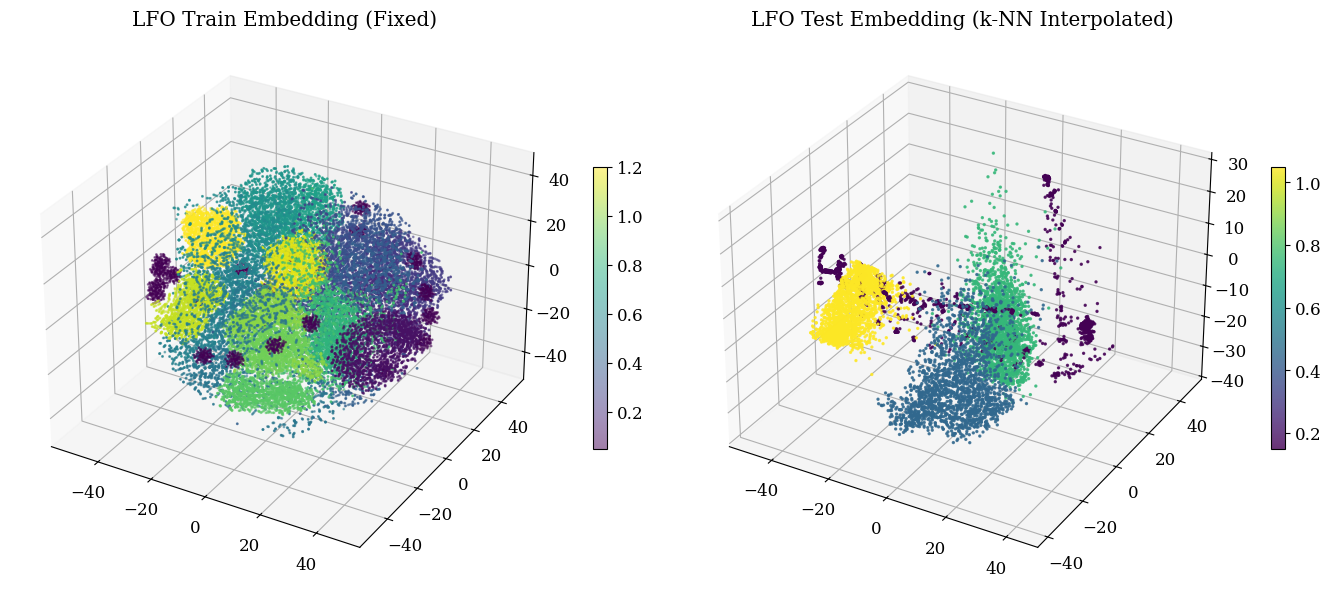

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': '3d'})

ax = axes[0]
sc = ax.scatter(Y_train_lfo[:,0], Y_train_lfo[:,1], Y_train_lfo[:,2], 
                c=st_labels[lfo_train_idx], cmap='viridis', s=1, alpha=0.5)
ax.set_title("LFO Train Embedding (Fixed)")
fig.colorbar(sc, ax=ax, shrink=0.5)

ax = axes[1]
sc2 = ax.scatter(Y_test_lfo[:,0], Y_test_lfo[:,1], Y_test_lfo[:,2], 
                 c=st_labels[lfo_test_idx], cmap='viridis', s=2, alpha=0.8)
ax.set_title("LFO Test Embedding (k-NN Interpolated)")
fig.colorbar(sc2, ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()